# Import packages
run the following cell to import necessary packages to run the analysis

In [1]:
import os
from pathlib import Path
from tqdm.notebook import tqdm
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap

from ome_zarr.io import parse_url
from ome_zarr.reader import Reader, Node
from ome_zarr.utils import info
import napari
from napari.utils.colormaps import AVAILABLE_COLORMAPS

# Functions

In [2]:
def crop_image(image_data, start_roi, end_roi):
    assert len(start_roi) == len(end_roi), "The defined ROIs don't have the same number of dimensions."
    assert len(start_roi) >= 3, "Too many dimensions on the ROI."
    
    if len(start_roi) == 3:
        cropped = image_data[..., start_roi[0]:end_roi[0], start_roi[1]:end_roi[1], start_roi[2]:end_roi[2] ]
    elif len(start_roi) == 2:
        cropped = image_data[..., start_roi[0]:end_roi[0], start_roi[1]:end_roi[1]]
    
    return cropped

def max_z_projection(image_data):
    assert len(image_data.shape) >=3, "Not 3D data."

    return np.max(image_data, axis=1)

def create_rgb_composite(image_data, percentile_norm=(0, 95)):
    """
    Create RGB composite using napari colormaps (magenta, green, bop blue).
    
    Parameters:
    - image_data: array with shape (3, height, width)
    - percentile_norm: contrast stretching percentiles
    
    Returns:
    - RGB array with shape (height, width, 3)
    """
    magenta_cmap = AVAILABLE_COLORMAPS['magenta']
    green_cmap = AVAILABLE_COLORMAPS['green']
    bop_blue_cmap = AVAILABLE_COLORMAPS['bop blue']
    
    colormaps = [magenta_cmap, green_cmap, bop_blue_cmap]
    
    rgb_composite = np.zeros((image_data.shape[1], image_data.shape[2], 3))
    
    for ch_idx, cmap in enumerate(colormaps):
        if ch_idx == 1:
            continue  # skip green channel for now
        channel = image_data[ch_idx]
        # Normalize to 0-1 range
        vmin = np.percentile(channel.flatten(), percentile_norm[0])
        vmax = np.percentile(channel.flatten(), percentile_norm[1])
        normalized = np.clip((channel - vmin) / (vmax - vmin), 0, 1)
        
        # Apply colormap and get RGBA values
        rgba = cmap.map(normalized)  # shape: (height, width, 4)
        
        # Add RGB components (ignore alpha channel)
        rgb_composite += rgba[..., :3]
    
    # Clip to valid range after blending
    rgb_composite = np.clip(rgb_composite, 0, 1)
    
    return rgb_composite

def plot_images(image_data, color, percentiles=(0,95)):
    magenta_cmap = AVAILABLE_COLORMAPS['magenta']
    green_cmap = AVAILABLE_COLORMAPS['green']
    bop_blue_cmap = AVAILABLE_COLORMAPS['bop blue']
    
    # sample many points in [0, 1] to build an RGBA LUT
    x = np.linspace(0, 1, 256)
    magenta_rgba = magenta_cmap.map(x)      # shape (256, 4)
    green_rgba = green_cmap.map(x)
    bop_blue_rgba = bop_blue_cmap.map(x)

    # wrap as Matplotlib colormaps
    magenta_mpl = ListedColormap(magenta_rgba, name='napari_magenta')
    green_mpl = ListedColormap(green_rgba, name='napari_green')
    bop_blue_mpl = ListedColormap(bop_blue_rgba, name='napari_bop_blue')
    
    if color == True:
        luts = [magenta_mpl, green_mpl, bop_blue_mpl]
    else:
        luts = ['gray', 'gray', 'gray']
    
    plt.figure(figsize=(12,12))
    nr_chan = image_data.shape[0]
    subplot_pos = 1
    for chan in range(nr_chan):
        if chan == 1:
            continue  # skip green channel for now
        plt.subplot(1, nr_chan, subplot_pos)
        plt.imshow(
            image_data[chan],
            cmap=luts[chan],
            vmin=np.percentile(image_data[chan].flatten(), percentiles[0]),
            vmax=np.percentile(image_data[chan].flatten(), percentiles[1]),
        )
        plt.axis('off')
        subplot_pos += 1
    rgb_image = create_rgb_composite(image_data)
    plt.subplot(1, nr_chan, subplot_pos)
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.show()

# Reading data

Paste the path to the data below and store it as variable `str_path`.
When copying it from the site, the entire command should be:
```bash
napari --plugin napari-ome-zarr /path/to/data/in/hdd/
```
Paste the entire command to the code cell, delete everything except the napari call and replace the string in the variable `str_path`

In [3]:
str_path = "/media/npmartins/ZS_HDD6/Data/Ex010_Re01/20250325/processed_data/NPM_Ex010_Re03_gel_Im-02_AcquisitionBlock2_pt2_tile01.zarr"
data_path = Path(str_path)

In [4]:
zarr_file = parse_url(data_path, mode='r')
reader = Reader(zarr_file)
nodes = list(reader())
print(len(nodes)) # checking number of nodes in data. Should be = 1

1


## Getting file info

The next cell will print all the resolution levels present in the dataset. Choose the highest level one you can open in your computer.
Levels are zero (0) indexed, first one will be `reoslution_level = 0`

In [5]:
zarr_info = info(data_path)
img_info = list(zarr_info)[0].data

# for item in img_info:
#     print(item.shape)

/media/npmartins/ZS_HDD6/Data/Ex010_Re01/20250325/processed_data/NPM_Ex010_Re03_gel_Im-02_AcquisitionBlock2_pt2_tile01.zarr [zgroup]
 - metadata
   - Multiscales
   - OMERO
 - data
   - (1, 3, 415, 4084, 4084)
   - (1, 3, 207, 2042, 2042)
   - (1, 3, 103, 1021, 1021)
   - (1, 3, 51, 510, 510)
   - (1, 3, 25, 255, 255)
   - (1, 3, 12, 127, 127)
   - (1, 3, 12, 63, 63)
   - (1, 3, 12, 31, 31)
   - (1, 3, 12, 15, 15)


the next cell specifies the resolution level. Adjust depending on dataset and computer. Then run the following cell to load data.

In [6]:
resolution_level = 1


In [7]:
image_node = nodes[0]

dask_data = image_node.data
# print(len(dask_data))

image_array = dask_data[resolution_level]
print(image_array.shape)
image_array = image_array.squeeze()
print(image_array.shape)

(1, 3, 207, 2042, 2042)
(3, 207, 2042, 2042)


if loading and moving up and down `Z` is too slow, load the entire dataset into memory by uncommenting (removing # at each line) and runnning the following cell.

__Note__: this will need much more RAM!

In [ ]:
# image_node = nodes[0]

# dask_data = image_node.data
# # print(len(dask_data))

# image_array = dask_data[resolution_level]
# image_array = image_array.computer()
# print(image_array.shape)
# image_array = image_array.squeeze()
# print(image_array.shape)

## Load Napari

In [8]:
import napari

In [9]:
viewer = napari.Viewer()
layer1 = viewer.add_image(image_array[0], colormap='magenta')
layer2 = viewer.add_image(image_array[1], colormap='green')
layer3 = viewer.add_image(image_array[2], colormap='bop blue')

if you need to adjust contrast, run the next cell: change the min and max values to whatever value is best.
Comment and uncomment the best option for you (remove the # from the beginning of the line)

In [13]:
# for item in viewer.layers: viewer.layers[str(item)].contrast_limits=(0,600) # adjust B&C for all channels with the same value
# viewer.layers[str(viewer.layers[0])].contrast_limits=(0, 600) # adjust B&C for first channel (pan-labeling)
viewer.layers[str(viewer.layers[2])].contrast_limits=(0, 150) # adjust B&C for first channel (pan-labeling)

### Crop data

In [18]:
# roi_start = [1159, 429] #dims: y, x
roi_start = [37, 1067, 1302] # dims: z, y, x
# roi_end = [1454, 1001] #dims: y, x
roi_end = [43, 1428, 1781] # dims: z, y, x

In [19]:
# image_crop = image_array.compute()
# print(image_crop.shape)
image_crop = crop_image(image_array, roi_start, roi_end)
print(image_crop.shape)

(3, 6, 361, 479)


In [20]:
viewer = napari.Viewer()
layer1 = viewer.add_image(image_crop[0], colormap='magenta')
layer2 = viewer.add_image(image_crop[1], colormap='green')
layer3 = viewer.add_image(image_crop[2], colormap='bop blue')

In [54]:
for item in viewer.layers: viewer.layers[str(item)].contrast_limits=(0,1500)

Do a max projection

In [81]:
max_projection = max_z_projection(image_crop)
print(max_projection.shape)

(3, 361, 479)


# Create figure from image

/home/npmartins/miniforge3/envs/napari-env/lib/python3.10/site-packages/dask/array/core.py:1705: FutureWarning: The `numpy.interp` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(
/home/npmartins/miniforge3/envs/napari-env/lib/python3.10/site-packages/dask/array/core.py:1705: FutureWarning: The `numpy.interp` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(


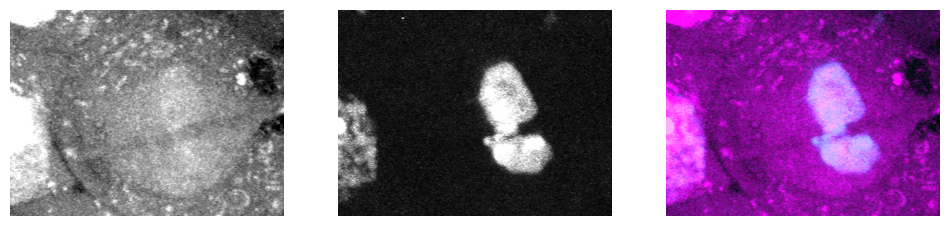

In [101]:
# to remove green channel
# max_projection[1] = np.zeros_like(max_projection[1])
plot_images(max_projection, False)

## Save data

In [65]:
from tifffile import imwrite

In [66]:
save_path = Path('/mnt/Data/nuno_martins/Image_data/ExM_processed_data/Share_data/Stg234_Mito_1/')
if not save_path.exists():
    save_path.mkdir(parents=True)

In [84]:
image = image_crop.compute()
image = np.clip(image, 0, 2**16-1)
image = image.astype(np.uint16)
image = np.moveaxis(image, 0, 1)
print(image.shape)

(78, 3, 517, 542)


In [85]:
imwrite(str(save_path)+'/Stg234_Mito_1_oocyte_'+str(resolution_level)+'.tif', image_crop, dtype=np.uint16, metadata={'axes': 'ZCYX'}, imagej=True)